In [ ]:
x=1

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import multimil as mtm
import multigrate as mtg

In [ ]:
from matplotlib import pyplot as plt
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import math
import random
import scvi
import torch

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
condition = 'lung_condition_coarse'
sample = 'sample'

In [ ]:
work_dir = '/lustre/groups/ml01/projects/2022_multigrate_anastasia.litinetskaya/snakemake/hyperparam/'

# Reference

In [ ]:
rna = sc.read(work_dir + "data/pp_clean/hlca_hvg_pearson.h5ad")
rna

In [ ]:
adata = mtg.data.organize_multiome_anndatas(
     adatas = [[rna]],
     layers=[[None]],
)
adata

In [ ]:
query = adata[adata.obs['split0'] == 'val'].copy()
adata = adata[adata.obs['split0'] == 'train'].copy()

In [ ]:
idx = adata.obs['sample'].sort_values().index
adata = adata[idx].copy()

In [ ]:
mtm.model.MultiVAE_MIL.setup_anndata(
    adata,
    rna_indices_end=2000,
    categorical_covariate_keys=[
        "sample",
        "lung_condition_coarse",
      ])

In [ ]:
mil = mtm.model.MultiVAE_MIL(
    adata, 
    losses=[
        "nb"
      ],
      loss_coefs={
        "kl": 1e-5,
        "integ": 0
      },
      classification=[
        "lung_condition_coarse"
      ],
      patient_label="sample",
      hierarchical_attn=False,
      drop_attn=False,
      aggr="attn",
      cov_aggr="attn",
      patient_in_vae=True,
      activation="leaky_relu",
      initialization="kaiming",
      attn_dim=8,
      cond_dim=32,
      n_layers_classifier=2,
      z_dim=16,
)

In [ ]:
mil.is_trained_ = True

In [ ]:
t_path = '/lustre/groups/ml01/projects/2022_multigrate_anastasia.litinetskaya/snakemake/hyperparam/data/multigrate/attention_dropout~False_attn_dim~8_batch_size~256_cond_dim~32_drop_attn~False_kl~0.001_lr~1e-05_n_layers_classifier~2_patient_batch_size~128_z_dim~16/0/checkpoints/epoch=49-step=300900.ckpt'

In [ ]:
train_state_dict = torch.load(t_path)['state_dict']
for key in list(train_state_dict.keys()):
    train_state_dict[key.replace('module.', '')] = train_state_dict.pop(key)

In [ ]:
mil.module.load_state_dict(train_state_dict)

In [17]:
# mil.train(
#     max_epochs=4, # setting to 200 is usually enough
#     batch_size=512,
#     lr=1e-4,
#     save_checkpoint_every_n_epochs=2,
#     path_to_checkpoints='/lustre/groups/ml01/projects/2022_multigrate_anastasia.litinetskaya/snakemake/test_checkpoints/'
# )

In [18]:
# mil.plot_losses()

In [19]:
# mil.get_model_output(batch_size=512)
# adata

In [20]:
# sc.pp.neighbors(adata, use_rep='latent')
# sc.tl.umap(adata)

In [21]:
# sc.pl.umap(
#     adata, 
#     color=[
#         "new_condition", 
#         "ann_level_1_core_transferred",
#         "ann_level_2_core_transferred",
#         "ann_level_3_core_transferred",
#         "sample",
#         "study"
#     ],
#     ncols=1)

# Query

In [22]:
idx = query.obs['sample'].sort_values().index
query = query[idx].copy()

In [ ]:
new_model = mtm.model.MultiVAE_MIL.load_query_data(query, use_prediction_labels=False, reference_model=mil)

In [ ]:
mil.module

In [ ]:
new_model.module

In [14]:
q_path = '/lustre/groups/ml01/projects/2022_multigrate_anastasia.litinetskaya/snakemake/hyperparam/data/multigrate/attention_dropout~False_attn_dim~8_batch_size~256_cond_dim~32_drop_attn~False_kl~0.001_lr~1e-05_n_layers_classifier~2_patient_batch_size~128_z_dim~16/0/query_checkpoints/epoch=49-step=300900/epoch=49-step=75400.ckpt'

In [49]:
query_state_dict = torch.load(q_path)['state_dict']

In [50]:
for key in list(query_state_dict.keys()):
    query_state_dict[key.replace('module.', '')] = query_state_dict.pop(key)
    key = key.replace('module.', '')
    query_state_dict[f'vae.{key}'] = query_state_dict.pop(key)

In [60]:
train_state_dict['vae.theta']

tensor([[-1.1434],
        [-0.8294],
        [-0.8091],
        ...,
        [-1.1114],
        [-0.8940],
        [-1.5602]], device='cuda:0')

In [61]:
query_state_dict['vae.theta']

tensor([[-1.1434],
        [-0.8294],
        [-0.8091],
        ...,
        [-1.1114],
        [-0.8940],
        [-1.5602]], device='cuda:0')

In [62]:
train_state_dict.update(query_state_dict)

In [53]:
for key in train_state_dict.keys():
    print(key)

vae.theta
vae.cont_covariate_embeddings.weight
vae.cont_covariate_curves.beta
vae.cont_covariate_curves.bias
vae.encoder_0.mlp.fc_layers.Layer 0.0.weight
vae.encoder_0.mlp.fc_layers.Layer 0.0.bias
vae.encoder_0.mlp.fc_layers.Layer 1.0.weight
vae.encoder_0.mlp.fc_layers.Layer 1.0.bias
vae.decoder_0.decoder.mlp.fc_layers.Layer 0.0.weight
vae.decoder_0.decoder.mlp.fc_layers.Layer 0.0.bias
vae.decoder_0.decoder.mlp.fc_layers.Layer 1.0.weight
vae.decoder_0.decoder.mlp.fc_layers.Layer 1.0.bias
vae.decoder_0.mean_decoder.0.weight
vae.decoder_0.mean_decoder.0.bias
vae.mu_0.weight
vae.mu_0.bias
vae.logvar_0.weight
vae.logvar_0.bias
vae.cat_covariate_embedding_0.weight
cell_level_aggregator.0.mlp.fc_layers.Layer 0.0.weight
cell_level_aggregator.0.mlp.fc_layers.Layer 0.0.bias
cell_level_aggregator.1.attention_V.0.weight
cell_level_aggregator.1.attention_V.0.bias
cell_level_aggregator.1.attention_U.0.weight
cell_level_aggregator.1.attention_U.0.bias
cell_level_aggregator.1.attention_weights.weight

In [52]:
for key in query_state_dict.keys():
    print(key)

vae.theta
vae.cont_covariate_embeddings.weight
vae.cont_covariate_curves.beta
vae.cont_covariate_curves.bias
vae.encoder_0.mlp.fc_layers.Layer 0.0.weight
vae.encoder_0.mlp.fc_layers.Layer 0.0.bias
vae.encoder_0.mlp.fc_layers.Layer 1.0.weight
vae.encoder_0.mlp.fc_layers.Layer 1.0.bias
vae.decoder_0.decoder.mlp.fc_layers.Layer 0.0.weight
vae.decoder_0.decoder.mlp.fc_layers.Layer 0.0.bias
vae.decoder_0.decoder.mlp.fc_layers.Layer 1.0.weight
vae.decoder_0.decoder.mlp.fc_layers.Layer 1.0.bias
vae.decoder_0.mean_decoder.0.weight
vae.decoder_0.mean_decoder.0.bias
vae.mu_0.weight
vae.mu_0.bias
vae.logvar_0.weight
vae.logvar_0.bias
vae.cat_covariate_embedding_0.weight


In [63]:
new_model.module.load_state_dict(train_state_dict)

<All keys matched successfully>

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:267: LightningDeprecationWarning: The `Callback.on_epoch_end` hook was deprecated in v1.6 and will be removed in v1.8. Please use `Callback.on_<train/validation/test>_epoch_end` instead.
  rank_zero_deprecation(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 50/50: 100%|██████████| 50/50 [04:23<00:00,  5.37s/it, loss=624, v_num=1]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [04:23<00:00,  5.26s/it, loss=624, v_num=1]


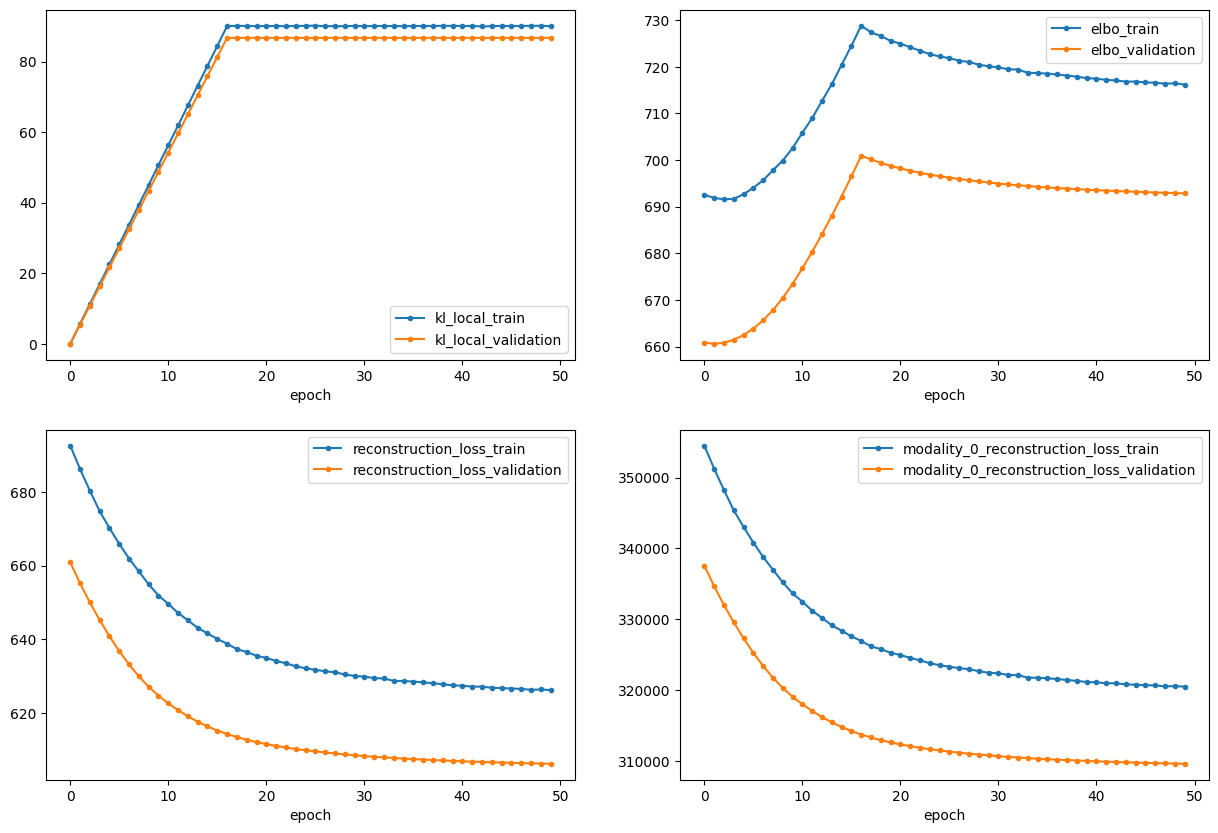

In [18]:
new_model.finetune_query(
    max_epochs=50, # setting to 200 is usually enough
    batch_size=512,
    lr=1e-4,
    weight_decay=0
)

In [65]:
new_model.is_trained_ = True

In [66]:
new_model.get_model_output(batch_size=512)
query

AnnData object with n_obs × n_vars = 428833 × 2000
    obs: "3'_or_5'", 'BMI', 'age_or_mean_of_age_range', 'age_range', 'anatomical_region_ccf_score', 'ancestry', 'ann_coarse_for_GWAS_and_modeling', 'ann_finest_level', 'ann_level_1', 'ann_level_2', 'ann_level_3', 'ann_level_4', 'ann_level_5', 'assay', 'cause_of_death', 'cell_type', 'core_or_extension', 'dataset', 'development_stage', 'disease', 'donor_id', 'fresh_or_frozen', 'log10_total_counts', 'lung_condition', 'mixed_ancestry', 'original_ann_level_1', 'original_ann_level_2', 'original_ann_level_3', 'original_ann_level_4', 'original_ann_level_5', 'original_ann_nonharmonized', 'reannotation_type', 'sample', 'scanvi_label', 'sequencing_platform', 'sex', 'smoking_status', 'study', 'subject_type', 'suspension_type', 'tissue', 'tissue_coarse_unharmonized', 'tissue_detailed_unharmonized', 'tissue_dissociation_protocol', 'tissue_level_2', 'tissue_level_3', 'tissue_sampling_method', 'total_counts', 'transf_ann_level_1_label', 'transf_ann_le

In [71]:
query.obs[condition]

001C_TTCTACATCCTCTAGC_adams                Healthy
001C_ATAAGAGGTTGCCTCT_adams                Healthy
001C_GGCTCGAGTAAACACA_adams                Healthy
001C_ACCCACTAGCACCGTC_adams                Healthy
001C_AAGGTTCTCCGATATG_adams                Healthy
                                           ...    
scrBT1430_GAACCTATCACTATTC_lambrechts    Carcinoma
scrBT1430_CGTTGGGTCGTCGTTC_lambrechts    Carcinoma
scrBT1430_GCAATCATCATCTGCC_lambrechts    Carcinoma
scrBT1430_CGTCAGGGTATCGCAT_lambrechts    Carcinoma
scrBT1430_AGCGTATGTAAGTGTA_lambrechts    Carcinoma
Name: lung_condition_coarse, Length: 428833, dtype: category
Categories (9, object): ['CF', 'COPD', 'COVID-19', 'Chronic rhinitis', ..., 'ILD', 'IPF', 'Carcinoma', 'Pneumonia non-COVID']

In [72]:
query.obs[f"predicted_{condition}"]

001C_TTCTACATCCTCTAGC_adams                Healthy
001C_ATAAGAGGTTGCCTCT_adams                Healthy
001C_GGCTCGAGTAAACACA_adams                Healthy
001C_ACCCACTAGCACCGTC_adams                Healthy
001C_AAGGTTCTCCGATATG_adams                Healthy
                                           ...    
scrBT1430_GAACCTATCACTATTC_lambrechts    Carcinoma
scrBT1430_CGTTGGGTCGTCGTTC_lambrechts    Carcinoma
scrBT1430_GCAATCATCATCTGCC_lambrechts    Carcinoma
scrBT1430_CGTCAGGGTATCGCAT_lambrechts    Carcinoma
scrBT1430_AGCGTATGTAAGTGTA_lambrechts    Carcinoma
Name: predicted_lung_condition_coarse, Length: 428833, dtype: category
Categories (7, object): ['COPD', 'COVID-19', 'Chronic rhinitis', 'Healthy', 'ILD', 'IPF', 'Carcinoma']

In [70]:
report = classification_report(
    query.obs[condition], query.obs[f"predicted_{condition}"], output_dict=True
)

/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/lustre/groups/ml01/workspace/anastasia.litinetskaya/miniconda3/envs/multimil/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels w

# Save

In [21]:
adata = adata.copy()
query = query.copy()

In [26]:
# otherwise there are issues with saving dicts with int keys
del adata.uns['modality_lengths']
del query.uns['modality_lengths']

In [27]:
adata.write('/lustre/groups/ml01/projects/2022_multigrate_anastasia.litinetskaya/hlca/data/integrated/ref.h5ad')

In [28]:
query.write('/lustre/groups/ml01/projects/2022_multigrate_anastasia.litinetskaya/hlca/data/integrated/query.h5ad')